In [1]:
import os
import math
import random
import json
from dataclasses import dataclass
from typing import Dict, List, Tuple
import time

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from skimage import measure

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [3]:
@dataclass
class Config:
    data_dir: str = "./data"
    batch_size: int = 128
    epochs_cls: int = 20
    lr: float = 1e-3
    weight_decay: float = 1e-4
    val_split: float = 0.2
    num_classes_cls: int = 100
    fast_mode: bool = False
    n_show_seg: int = 3

cfg = Config()

In [4]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

def get_cifar100_datasets():
    transform_base = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
    ])
    transform_aug = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
    ])

    imagenet_mean = (0.485, 0.456, 0.406)
    imagenet_std = (0.229, 0.224, 0.225)
    transform_resnet_train = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ])
    transform_resnet_eval = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std)
    ])

    ds_train_full = torchvision.datasets.CIFAR100(root=cfg.data_dir, train=True, download=True, transform=transform_base)
    ds_test = torchvision.datasets.CIFAR100(root=cfg.data_dir, train=False, download=True, transform=transform_base)

    n_total = len(ds_train_full)
    n_val = int(n_total * cfg.val_split)
    n_train = n_total - n_val
    ds_train, ds_val = random_split(ds_train_full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

    ds_train_aug = torchvision.datasets.CIFAR100(root=cfg.data_dir, train=True, download=True, transform=transform_aug)
    train_indices = ds_train.indices
    ds_train_aug = Subset(ds_train_aug, train_indices)

    ds_train_resnet = torchvision.datasets.CIFAR100(root=cfg.data_dir, train=True, download=True, transform=transform_resnet_train)
    ds_train_resnet = Subset(ds_train_resnet, train_indices)
    ds_val_resnet = torchvision.datasets.CIFAR100(root=cfg.data_dir, train=True, download=True, transform=transform_resnet_eval)
    ds_val_resnet = Subset(ds_val_resnet, ds_val.indices)
    ds_test_resnet = torchvision.datasets.CIFAR100(root=cfg.data_dir, train=False, download=True, transform=transform_resnet_eval)

    return {
        'train_base': ds_train,
        'val_base': ds_val,
        'test_base': ds_test,
        'train_aug': ds_train_aug,
        'train_resnet': ds_train_resnet,
        'val_resnet': ds_val_resnet,
        'test_resnet': ds_test_resnet,
    }

datasets_cls = get_cifar100_datasets()

Files already downloaded and verified


d:\Storage\Projects\dpo\dpo\homeworks\HW06\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


In [5]:
train_loader_base = DataLoader(datasets_cls['train_base'], batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader_base = DataLoader(datasets_cls['val_base'], batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_base = DataLoader(datasets_cls['test_base'], batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)

train_loader_aug = DataLoader(datasets_cls['train_aug'], batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True)

train_loader_resnet = DataLoader(datasets_cls['train_resnet'], batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader_resnet = DataLoader(datasets_cls['val_resnet'], batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader_resnet = DataLoader(datasets_cls['test_resnet'], batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [6]:
x, y = next(iter(train_loader_base))
print("Base train batch: x shape", x.shape, "y shape", y.shape)

Base train batch: x shape torch.Size([128, 3, 32, 32]) y shape torch.Size([128])


Примеры из train_base (без аугментаций):


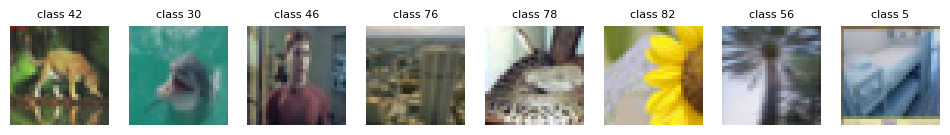

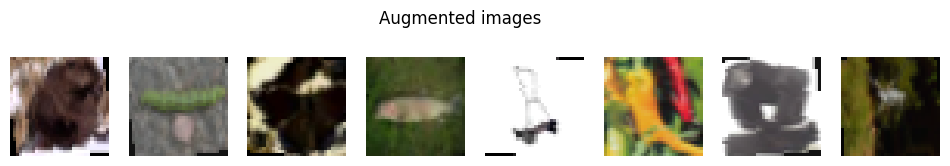

In [7]:
def denorm_cifar100(x, mean=CIFAR100_MEAN, std=CIFAR100_STD):
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    return x * std + mean

def show_images(loader, n=8, denorm_func=denorm_cifar100):
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()
    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = denorm_func(x[i]).clamp(0,1).permute(1,2,0).numpy()
        plt.imshow(img)
        plt.title(f"class {y[i].item()}", fontsize=8)
        plt.axis('off')
    plt.show()

print("Примеры из train_base (без аугментаций):")
show_images(train_loader_base)

#пример аугментации
x_aug, _ = next(iter(train_loader_aug))
plt.figure(figsize=(12, 2))
for i in range(8):
    plt.subplot(1,8,i+1)
    img = denorm_cifar100(x_aug[i]).clamp(0,1).permute(1,2,0).numpy()
    plt.imshow(img)
    plt.axis('off')
plt.suptitle("Augmented images")
plt.show()

plt.figure(figsize=(12, 2))
for i in range(8):
    plt.subplot(1,8,i+1)
    img = denorm_cifar100(x_aug[i]).clamp(0,1).permute(1,2,0).numpy()
    plt.imshow(img)
    plt.axis('off')
plt.savefig("artifacts/figures/augmentations_preview.png", bbox_inches='tight')
plt.close()

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def build_resnet18(num_classes=100):
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        pred = torch.argmax(logits, dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        pred = torch.argmax(logits, dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

def fit(model, train_loader, val_loader, optimizer, criterion, epochs, verbose=True):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if verbose:
            print(f"Epoch {epoch:2d}/{epochs} | train loss {train_loss:.4f}, acc {train_acc:.3f} | val loss {val_loss:.4f}, acc {val_acc:.3f}")
    return history

In [10]:
criterion = nn.CrossEntropyLoss()
results = []

print("\n========== C1: simple-cnn-base ==========")
model_c1 = SimpleCNN(num_classes=cfg.num_classes_cls).to(DEVICE)
optimizer = torch.optim.Adam(model_c1.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
hist_c1 = fit(model_c1, train_loader_base, val_loader_base, optimizer, criterion, epochs=cfg.epochs_cls)
best_val_acc_c1 = max(hist_c1['val_acc'])
results.append({'experiment_id': 'C1', 'model': 'SimpleCNN', 'augmentations': False, 'pretrained': False, 'best_val_acc': best_val_acc_c1})


========== C1: simple-cnn-base ==========
Epoch  1/20 | train loss 3.7982, acc 0.121 | val loss 3.3170, acc 0.195
Epoch  2/20 | train loss 3.0298, acc 0.252 | val loss 2.8903, acc 0.281
Epoch  3/20 | train loss 2.6509, acc 0.330 | val loss 2.6767, acc 0.317
Epoch  4/20 | train loss 2.3714, acc 0.388 | val loss 2.5494, acc 0.356
Epoch  5/20 | train loss 2.1563, acc 0.436 | val loss 2.4642, acc 0.376
Epoch  6/20 | train loss 1.9522, acc 0.480 | val loss 2.4302, acc 0.385
Epoch  7/20 | train loss 1.7839, acc 0.518 | val loss 2.4687, acc 0.397
Epoch  8/20 | train loss 1.6097, acc 0.557 | val loss 2.5051, acc 0.391
Epoch  9/20 | train loss 1.4570, acc 0.598 | val loss 2.4929, acc 0.402
Epoch 10/20 | train loss 1.3005, acc 0.633 | val loss 2.6519, acc 0.396
Epoch 11/20 | train loss 1.1650, acc 0.669 | val loss 2.7086, acc 0.394
Epoch 12/20 | train loss 1.0385, acc 0.698 | val loss 2.8547, acc 0.396
Epoch 13/20 | train loss 0.9118, acc 0.732 | val loss 3.0276, acc 0.391
Epoch 14/20 | train l

In [11]:
print("\n========== C2: simple-cnn-aug ==========")
model_c2 = SimpleCNN(num_classes=cfg.num_classes_cls).to(DEVICE)
optimizer = torch.optim.Adam(model_c2.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
hist_c2 = fit(model_c2, train_loader_aug, val_loader_base, optimizer, criterion, epochs=cfg.epochs_cls)
best_val_acc_c2 = max(hist_c2['val_acc'])
results.append({'experiment_id': 'C2', 'model': 'SimpleCNN', 'augmentations': True, 'pretrained': False, 'best_val_acc': best_val_acc_c2})


========== C2: simple-cnn-aug ==========
Epoch  1/20 | train loss 3.9028, acc 0.107 | val loss 3.3598, acc 0.197
Epoch  2/20 | train loss 3.2496, acc 0.212 | val loss 3.0415, acc 0.248
Epoch  3/20 | train loss 2.9564, acc 0.266 | val loss 2.8110, acc 0.302
Epoch  4/20 | train loss 2.7507, acc 0.307 | val loss 2.6631, acc 0.337
Epoch  5/20 | train loss 2.6014, acc 0.340 | val loss 2.5523, acc 0.359
Epoch  6/20 | train loss 2.4776, acc 0.367 | val loss 2.4954, acc 0.367
Epoch  7/20 | train loss 2.3689, acc 0.389 | val loss 2.5333, acc 0.369
Epoch  8/20 | train loss 2.3008, acc 0.408 | val loss 2.4280, acc 0.391
Epoch  9/20 | train loss 2.2141, acc 0.421 | val loss 2.3597, acc 0.403
Epoch 10/20 | train loss 2.1553, acc 0.434 | val loss 2.3720, acc 0.404
Epoch 11/20 | train loss 2.0859, acc 0.447 | val loss 2.3237, acc 0.409
Epoch 12/20 | train loss 2.0359, acc 0.459 | val loss 2.3349, acc 0.413
Epoch 13/20 | train loss 1.9875, acc 0.469 | val loss 2.2042, acc 0.435
Epoch 14/20 | train lo

In [12]:
print("\n========== C3: resnet18-head-only ==========")
model_c3 = build_resnet18(num_classes=cfg.num_classes_cls).to(DEVICE)
# freeze all but fc
for param in model_c3.parameters():
    param.requires_grad = False

# Разморозить только классификационную голову (fc)
for param in model_c3.fc.parameters():
    param.requires_grad = True
    
optimizer = torch.optim.Adam(model_c3.fc.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
hist_c3 = fit(model_c3, train_loader_resnet, val_loader_resnet, optimizer, criterion, epochs=cfg.epochs_cls)
best_val_acc_c3 = max(hist_c3['val_acc'])
results.append({'experiment_id': 'C3', 'model': 'ResNet18', 'augmentations': True, 'best_val_acc': best_val_acc_c3})


========== C3: resnet18-head-only ==========
Epoch  1/20 | train loss 3.4904, acc 0.211 | val loss 2.4871, acc 0.392
Epoch  2/20 | train loss 2.7688, acc 0.329 | val loss 2.1319, acc 0.453
Epoch  3/20 | train loss 2.5924, acc 0.357 | val loss 1.9968, acc 0.475
Epoch  4/20 | train loss 2.5250, acc 0.371 | val loss 1.9524, acc 0.484
Epoch  5/20 | train loss 2.4785, acc 0.380 | val loss 1.9015, acc 0.492
Epoch  6/20 | train loss 2.4299, acc 0.390 | val loss 1.8765, acc 0.497
Epoch  7/20 | train loss 2.4183, acc 0.392 | val loss 1.8853, acc 0.493
Epoch  8/20 | train loss 2.3816, acc 0.398 | val loss 1.8685, acc 0.497
Epoch  9/20 | train loss 2.3749, acc 0.400 | val loss 1.8507, acc 0.502
Epoch 10/20 | train loss 2.3559, acc 0.407 | val loss 1.8220, acc 0.506
Epoch 11/20 | train loss 2.3696, acc 0.403 | val loss 1.8111, acc 0.508
Epoch 12/20 | train loss 2.3413, acc 0.407 | val loss 1.8011, acc 0.513
Epoch 13/20 | train loss 2.3367, acc 0.407 | val loss 1.8303, acc 0.503
Epoch 14/20 | trai

In [13]:
print("\n========== C4: resnet18-finetune ==========")
model_c4 = build_resnet18(num_classes=cfg.num_classes_cls).to(DEVICE)
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
for param in model_c4.fc.parameters():
    param.requires_grad = True
params = [
    {'params': model_c4.layer4.parameters(), 'lr': cfg.lr / 10},
    {'params': model_c4.fc.parameters(), 'lr': cfg.lr}
]
optimizer = torch.optim.Adam(params, weight_decay=cfg.weight_decay)
hist_c4 = fit(model_c4, train_loader_resnet, val_loader_resnet, optimizer, criterion, epochs=cfg.epochs_cls)
best_val_acc_c4 = max(hist_c4['val_acc'])
results.append({'experiment_id': 'C4', 'model': 'ResNet18', 'augmentations': True, 'best_val_acc': best_val_acc_c4})

# Определим лучшую модель по val accuracy
best_experiment = max(results, key=lambda x: x['best_val_acc'])
print(f"\nBest model: {best_experiment['experiment_id']} with val_acc {best_experiment['best_val_acc']:.4f}")


========== C4: resnet18-finetune ==========
Epoch  1/20 | train loss 2.7560, acc 0.322 | val loss 1.5901, acc 0.546
Epoch  2/20 | train loss 1.9962, acc 0.473 | val loss 1.3424, acc 0.616
Epoch  3/20 | train loss 1.8163, acc 0.513 | val loss 1.2595, acc 0.632
Epoch  4/20 | train loss 1.6966, acc 0.543 | val loss 1.2113, acc 0.648
Epoch  5/20 | train loss 1.6114, acc 0.567 | val loss 1.1959, acc 0.652
Epoch  6/20 | train loss 1.5279, acc 0.586 | val loss 1.1491, acc 0.668
Epoch  7/20 | train loss 1.4713, acc 0.599 | val loss 1.1192, acc 0.679
Epoch  8/20 | train loss 1.4378, acc 0.607 | val loss 1.1225, acc 0.680
Epoch  9/20 | train loss 1.3837, acc 0.620 | val loss 1.1243, acc 0.682
Epoch 10/20 | train loss 1.3427, acc 0.632 | val loss 1.1097, acc 0.685
Epoch 11/20 | train loss 1.2908, acc 0.647 | val loss 1.1015, acc 0.693
Epoch 12/20 | train loss 1.2585, acc 0.654 | val loss 1.1508, acc 0.682
Epoch 13/20 | train loss 1.2232, acc 0.661 | val loss 1.1210, acc 0.690
Epoch 14/20 | train

In [15]:
if best_experiment['experiment_id'] == 'C1':
    best_model = model_c1
    test_loader = test_loader_base
elif best_experiment['experiment_id'] == 'C2':
    best_model = model_c2
    test_loader = test_loader_base
elif best_experiment['experiment_id'] == 'C3':
    best_model = model_c3
    test_loader = test_loader_resnet
else:
    best_model = model_c4
    test_loader = test_loader_resnet

test_loss, test_acc = evaluate(best_model, test_loader, criterion)
print(f"Test accuracy: {test_acc:.4f}")

# Сохраним лучшую модель
torch.save(best_model.state_dict(), "artifacts/best_classifier.pt")

# Сохраним конфиг
config_dict = {
    'experiment_id': best_experiment['experiment_id'],
    'model': best_experiment['model'],
    'dataset': 'CIFAR100',
    'num_classes': cfg.num_classes_cls,
    'augmentations': best_experiment['augmentations'],
    'pretrained': True,
    'pretrained_weights': 'ImageNet',
    'freeze_backbone': (best_experiment['experiment_id'] == 'C3'),
    'trainable_layers': ['fc'] if best_experiment['experiment_id'] == 'C3' else ['layer4', 'fc'],
    'learning_rate': cfg.lr,
    'batch_size': cfg.batch_size,
    'epochs': cfg.epochs_cls,
    'optimizer': 'Adam',
    'weight_decay': cfg.weight_decay,
    'seed': SEED,
    'test_accuracy': test_acc,
    'best_val_accuracy': best_experiment['best_val_acc']
}
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(config_dict, f, indent=2)

Test accuracy: 0.7046


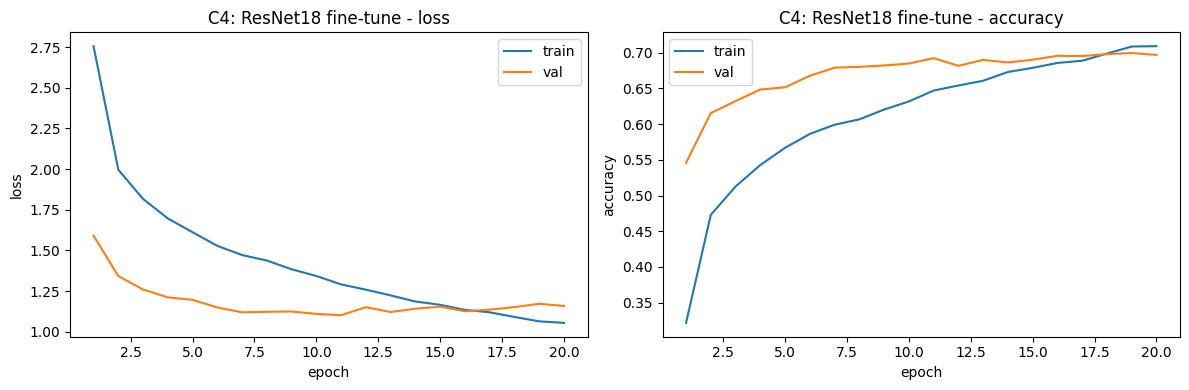

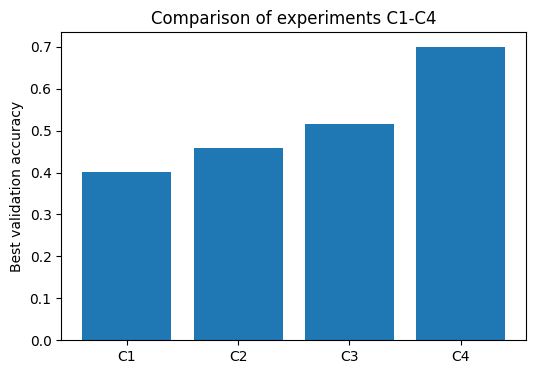

In [16]:
def plot_history(hist, title):
    epochs = range(1, len(hist['train_loss'])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, hist['train_loss'], label='train')
    plt.plot(epochs, hist['val_loss'], label='val')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.title(f'{title} - loss')
    plt.subplot(1,2,2)
    plt.plot(epochs, hist['train_acc'], label='train')
    plt.plot(epochs, hist['val_acc'], label='val')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()
    plt.title(f'{title} - accuracy')
    plt.tight_layout()
    plt.savefig(f"artifacts/figures/classification_curves_best.png", bbox_inches='tight')
    plt.show()

if best_experiment['experiment_id'] == 'C1':
    plot_history(hist_c1, "C1: SimpleCNN base")
elif best_experiment['experiment_id'] == 'C2':
    plot_history(hist_c2, "C2: SimpleCNN aug")
elif best_experiment['experiment_id'] == 'C3':
    plot_history(hist_c3, "C3: ResNet18 head-only")
else:
    plot_history(hist_c4, "C4: ResNet18 fine-tune")

# Сравнение C1-C4
plt.figure(figsize=(6,4))
labels = [r['experiment_id'] for r in results]
vals = [r['best_val_acc'] for r in results]
plt.bar(labels, vals)
plt.ylabel('Best validation accuracy')
plt.title('Comparison of experiments C1-C4')
plt.savefig("artifacts/figures/classification_compare.png", bbox_inches='tight')
plt.show()

Dataset size: 3680
Image size: (394, 500)
Mask size: (394, 500)
Mask pixel values (unique): [1 2 3]


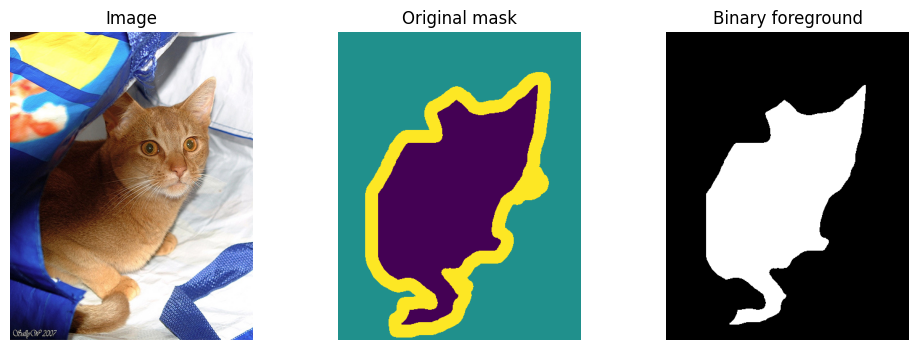

In [17]:
oxford_root = os.path.join(cfg.data_dir, "oxford-iiit-pet")
# Для сегментации используем split='trainval' (объединяет train и test), мы возьмём весь датасет для оценки
ds_pet = torchvision.datasets.OxfordIIITPet(root=oxford_root, split='trainval', target_types='segmentation', download=True)

print("Dataset size:", len(ds_pet))
sample_img, sample_mask = ds_pet[0]
print("Image size:", sample_img.size)
print("Mask size:", sample_mask.size)
print("Mask pixel values (unique):", np.unique(np.array(sample_mask)))

# %%
# Преобразуем в бинарную маску (foreground = 1, else 0)
def binary_mask_from_pet(mask_pil):
    mask = np.array(mask_pil)
    return (mask == 1).astype(np.uint8)   # класс 1 = foreground

# Визуализация примера
img, mask = ds_pet[0]
binary = binary_mask_from_pet(mask)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title('Image'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask); plt.title('Original mask'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(binary, cmap='gray'); plt.title('Binary foreground'); plt.axis('off')
plt.show()

In [18]:
weights_seg = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model_seg = deeplabv3_resnet50(weights=weights_seg)
model_seg.to(DEVICE)
model_seg.eval()

# Preprocessing для модели (соответствует весам)
preprocess_seg = weights_seg.transforms()

# Индексы классов cat и dog в COCO
COCO_CAT_IDX = 8
COCO_DOG_IDX = 12

In [19]:
@torch.no_grad()
def predict_pet_mask(img_pil, threshold=0.5, remove_small=False, min_area=500):
    x = preprocess_seg(img_pil).unsqueeze(0).to(DEVICE)
    H, W = x.shape[-2:]                     # размер после предобработки
    output = model_seg(x)['out'][0]         # (21, H, W)
    
    probs = torch.softmax(output, dim=0)    # (21, H, W)
    prob_cat = probs[COCO_CAT_IDX]
    prob_dog = probs[COCO_DOG_IDX]
    prob_foreground = torch.max(prob_cat, prob_dog)   # (H, W)
    
    if threshold is None:
        pred_class = torch.argmax(output, dim=0)
        mask_cat = (pred_class == COCO_CAT_IDX)
        mask_dog = (pred_class == COCO_DOG_IDX)
        mask = (mask_cat | mask_dog).cpu().numpy().astype(np.uint8)
    else:
        mask = (prob_foreground > threshold).cpu().numpy().astype(np.uint8)
    
    if remove_small:
        labels = measure.label(mask, connectivity=2)
        for region in measure.regionprops(labels):
            if region.area < min_area:
                mask[labels == region.label] = 0
    
    return mask, (H, W), prob_foreground.cpu().numpy()

def iou_binary(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / (union + 1e-9)

def precision_recall(pred, gt):
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, np.logical_not(gt)).sum()
    fn = np.logical_and(np.logical_not(pred), gt).sum()
    prec = tp / (tp + fp + 1e-9)
    rec = tp / (tp + fn + 1e-9)
    return prec, rec

In [20]:
# Теперь в цикле оценки:
indices = list(range(len(ds_pet)))
if cfg.fast_mode:
    indices = indices[:100]

metrics_v1 = {'iou': [], 'precision': [], 'recall': []}
metrics_v2 = {'iou': [], 'precision': [], 'recall': []}

for idx in indices:
    img_pil, mask_pil = ds_pet[idx]
    gt_binary = binary_mask_from_pet(mask_pil)
    
    # V1
    pred_v1, (H, W), _ = predict_pet_mask(img_pil, threshold=None, remove_small=False)
    gt_resized = TF.resize(Image.fromarray((gt_binary * 255).astype(np.uint8)),
                           size=(H, W), interpolation=InterpolationMode.NEAREST)
    gt_binary_resized = np.array(gt_resized) > 0
    iou_v1 = iou_binary(pred_v1, gt_binary_resized)
    prec_v1, rec_v1 = precision_recall(pred_v1, gt_binary_resized)
    metrics_v1['iou'].append(iou_v1)
    metrics_v1['precision'].append(prec_v1)
    metrics_v1['recall'].append(rec_v1)
    
    # V2
    pred_v2, (H, W), _ = predict_pet_mask(img_pil, threshold=0.5, remove_small=True, min_area=500)
    # gt_binary_resized уже есть, но можно пересчитать (размер тот же)
    iou_v2 = iou_binary(pred_v2, gt_binary_resized)
    prec_v2, rec_v2 = precision_recall(pred_v2, gt_binary_resized)
    metrics_v2['iou'].append(iou_v2)
    metrics_v2['precision'].append(prec_v2)
    metrics_v2['recall'].append(rec_v2)

# Агрегация
mean_iou_v1 = np.mean(metrics_v1['iou'])
mean_prec_v1 = np.mean(metrics_v1['precision'])
mean_rec_v1 = np.mean(metrics_v1['recall'])
mean_iou_v2 = np.mean(metrics_v2['iou'])
mean_prec_v2 = np.mean(metrics_v2['precision'])
mean_rec_v2 = np.mean(metrics_v2['recall'])

print("V1 (argmax):")
print(f"  mean IoU = {mean_iou_v1:.4f}")
print(f"  mean Precision = {mean_prec_v1:.4f}")
print(f"  mean Recall = {mean_rec_v1:.4f}")
print("V2 (threshold=0.5 + remove small):")
print(f"  mean IoU = {mean_iou_v2:.4f}")
print(f"  mean Precision = {mean_prec_v2:.4f}")
print(f"  mean Recall = {mean_rec_v2:.4f}")

V1 (argmax):
  mean IoU = 0.7572
  mean Precision = 0.7708
  mean Recall = 0.9787
V2 (threshold=0.5 + remove small):
  mean IoU = 0.7591
  mean Precision = 0.7756
  mean Recall = 0.9748


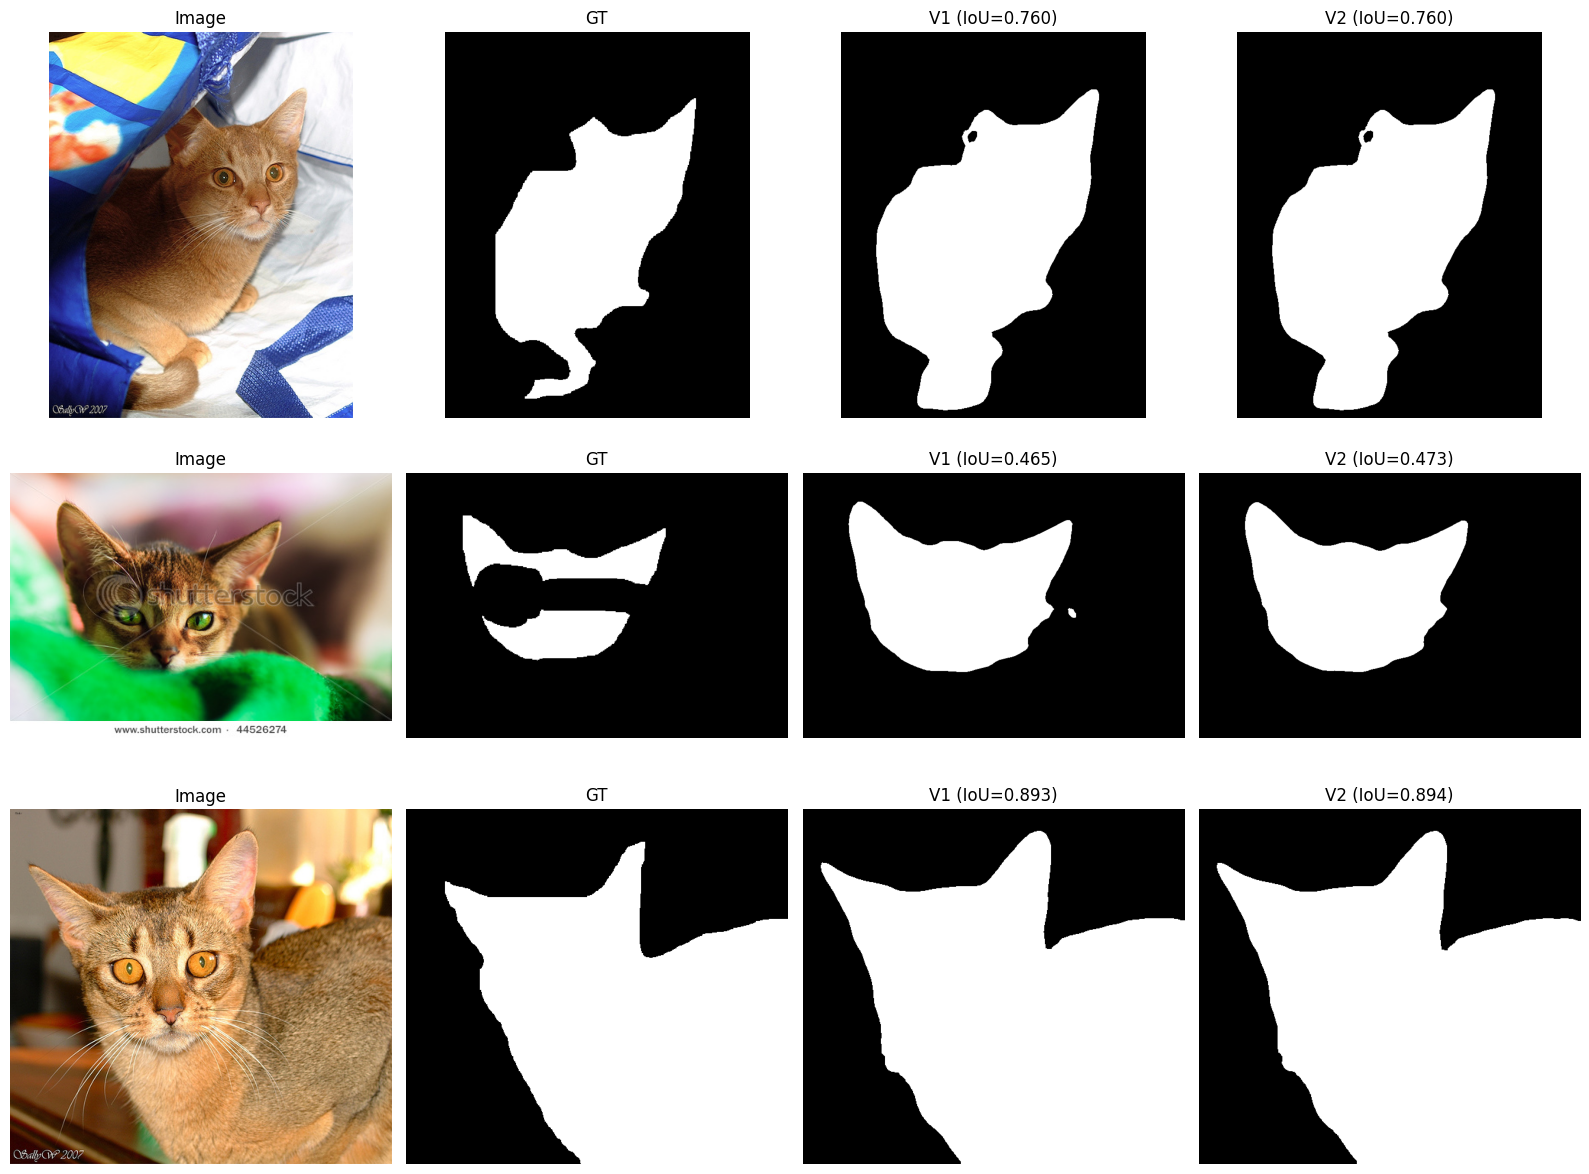

In [21]:
n_show = min(cfg.n_show_seg, len(ds_pet))
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show))
if n_show == 1:
    axes = axes.reshape(1, -1)

for i in range(n_show):
    img_pil, mask_pil = ds_pet[i]
    gt_binary = binary_mask_from_pet(mask_pil)
    
    # Получаем предсказания и размеры
    pred_v1, (H1, W1), _ = predict_pet_mask(img_pil, threshold=None)
    pred_v2, (H2, W2), _ = predict_pet_mask(img_pil, threshold=0.5, remove_small=True)
    
    # Приводим GT к размеру предсказания (используем размер от V1, он будет одинаковым)
    gt_resized = TF.resize(Image.fromarray((gt_binary * 255).astype(np.uint8)),
                           size=(H1, W1), interpolation=InterpolationMode.NEAREST)
    gt_binary_resized = np.array(gt_resized) > 0
    
    iou_v1 = iou_binary(pred_v1, gt_binary_resized)
    iou_v2 = iou_binary(pred_v2, gt_binary_resized)
    
    axes[i,0].imshow(img_pil)
    axes[i,0].set_title('Image')
    axes[i,0].axis('off')
    axes[i,1].imshow(gt_binary_resized, cmap='gray')
    axes[i,1].set_title('GT')
    axes[i,1].axis('off')
    axes[i,2].imshow(pred_v1, cmap='gray')
    axes[i,2].set_title(f'V1 (IoU={iou_v1:.3f})')
    axes[i,2].axis('off')
    axes[i,3].imshow(pred_v2, cmap='gray')
    axes[i,3].set_title(f'V2 (IoU={iou_v2:.3f})')
    axes[i,3].axis('off')

plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png", bbox_inches='tight')
plt.show()

In [23]:
import pandas as pd

# Создадим датафрейм для всех экспериментов
data = []
# Классификация
for r in results:
    data.append({
        'experiment_id': r['experiment_id'],
        'task': 'classification',
        'dataset': 'CIFAR100',
        'seed': SEED,
        'model_summary': r['model'],
        'optimizer': 'Adam',
        'lr': cfg.lr,
        'epochs_trained': cfg.epochs_cls,
        'best_val_accuracy': r['best_val_acc'],
        'test_accuracy': test_acc if r['experiment_id'] == best_experiment['experiment_id'] else None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': f"aug={r['augmentations']}"
    })
# Сегментация V1
data.append({
    'experiment_id': 'V1',
    'task': 'segmentation',
    'dataset': 'OxfordIIITPet',
    'seed': SEED,
    'model_summary': 'DeepLabV3_ResNet50 (COCO)',
    'optimizer': 'inference only',
    'lr': None,
    'epochs_trained': 0,
    'best_val_accuracy': None,
    'test_accuracy': None,
    'precision': mean_prec_v1,
    'recall': mean_rec_v1,
    'mean_iou': mean_iou_v1,
    'notes': 'argmax'
})
# Сегментация V2
data.append({
    'experiment_id': 'V2',
    'task': 'segmentation',
    'dataset': 'OxfordIIITPet',
    'seed': SEED,
    'model_summary': 'DeepLabV3_ResNet50 (COCO)',
    'optimizer': 'inference only',
    'lr': None,
    'epochs_trained': 0,
    'best_val_accuracy': None,
    'test_accuracy': None,
    'precision': mean_prec_v2,
    'recall': mean_rec_v2,
    'mean_iou': mean_iou_v2,
    'notes': 'threshold=0.5 + remove small components (area<500)'
})

df = pd.DataFrame(data)
df.to_csv("artifacts/runs.csv", index=False)
print("runs.csv saved.")

runs.csv saved.


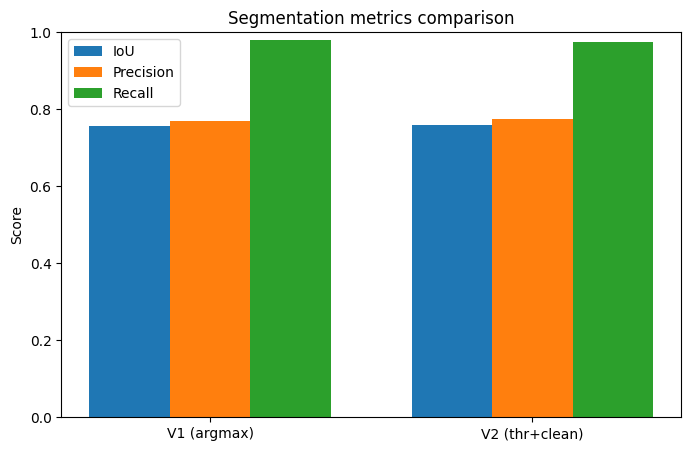

In [24]:
labels = ['V1 (argmax)', 'V2 (thr+clean)']
iou_vals = [mean_iou_v1, mean_iou_v2]
prec_vals = [mean_prec_v1, mean_prec_v2]
rec_vals = [mean_rec_v1, mean_rec_v2]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width, iou_vals, width, label='IoU')
rects2 = ax.bar(x, prec_vals, width, label='Precision')
rects3 = ax.bar(x + width, rec_vals, width, label='Recall')
ax.set_ylabel('Score')
ax.set_title('Segmentation metrics comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1)
plt.savefig("artifacts/figures/segmentation_metrics.png", bbox_inches='tight')
plt.show()